In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
current_dir = "/home/nfash/EECS_545"

import h5py
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import display, Javascript
import plotly.express as px
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer,KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error,get_scorer_names
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression,SGDClassifier,BayesianRidge
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.combine import *
from imblearn.under_sampling import *
from imblearn.over_sampling import *
from imblearn.pipeline import Pipeline
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import VotingClassifier,StackingClassifier

import keras
print(keras.__version__)
import tensorflow as tf

from sklearn.model_selection import train_test_split

2025-03-13 17:40:13.468568: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-13 17:40:13.472013: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-13 17:40:13.491082: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741902013.540458 4162421 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741902013.556839 4162421 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


3.5.0


In [27]:
class DataPreprocessor:
    def __init__(self):
        self.preprocessor = None
        self.train_columns = None

    def fit_transform(self, df):
        """Preprocess training data and store transformations."""
        df = df.copy()
        df = self._drop_irrelevant_columns(df)
        df = self._drop_train_only_columns(df)
        categorical_cols, numerical_cols = self._identify_column_types(df)
        
        # Define preprocessing pipelines
        numerical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            #("imputer", KNNImputer()),
            ("scaler", StandardScaler())
        ])
        
        categorical_pipeline = Pipeline([
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        
        self.preprocessor = ColumnTransformer([
            ("num", numerical_pipeline, numerical_cols),
            ("cat", categorical_pipeline, categorical_cols)
        ])
        
        transformed_data = self.preprocessor.fit_transform(df)
        
        cat_feature_names = self.preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_cols)
        all_columns = numerical_cols + list(cat_feature_names)
        
        df_processed = pd.DataFrame(transformed_data, columns=all_columns)
        df_processed["isic_id"] = df["isic_id"].values
        df_processed["target"] = df["target"].values
        
        self.train_columns = df_processed.columns  # Store train columns
        return df_processed

    def transform(self, df):
        """Preprocess test data using stored transformations from training."""
        df = df.copy()
        df = self._drop_irrelevant_columns(df)
        
        transformed_data = self.preprocessor.transform(df)
        cat_feature_names = self.preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out()
        all_columns = self.train_columns[:-2]  # Exclude 'isic_id' and 'target'
        
        df_processed = pd.DataFrame(transformed_data, columns=all_columns)
        df_processed["isic_id"] = df["isic_id"].values
        # df_processed["target"] = df["target"].values
        
        # Align test dataset with train columns
        df_processed = self._align_train_test_columns(df_processed)
        return df_processed

    def _drop_irrelevant_columns(self, df):
        """Remove unnecessary columns."""
        return df.drop(columns=['patient_id','image_type', 'tbp_tile_type', 'attribution', 'copyright_license'], errors="ignore")

    def _drop_train_only_columns(self,df):
        """Remove columns that are present only in the train set and not in the test set"""
        drop_train_only_columns = [
            'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5',
            'mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence'
            ]
        return df.drop(columns=drop_train_only_columns,errors='ignore')
        

    def _identify_column_types(self, df):
        """Identify categorical and numerical columns, excluding 'isic_id' and 'target'."""
        categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        categorical_cols = [col for col in categorical_cols if col != "isic_id"]
        numerical_cols = [col for col in numerical_cols if col != "target"]
        return categorical_cols, numerical_cols
    
    def _align_train_test_columns(self, df):
        """Ensure test data has the same columns as train data."""
        train_cols = list(self.train_columns)
        train_cols.remove('target')
        missing_cols = set(train_cols) - set(df.columns)
        for col in missing_cols:
            df[col] = 0
        return df[train_cols]

    
def resampler_data(X, Y):
    
    # Apply undersampling only on numerical data
    resampler = RandomUnderSampler(sampling_strategy=0.1,)
    X_resampled, Y_resampled = resampler.fit_resample(X,Y)
    
    # now apply over sampling for the minorit class
    resampler = RandomOverSampler(sampling_strategy=0.3)
    X_resampled, Y_resampled = resampler.fit_resample(X_resampled, Y_resampled)

    print("X_final shape;",X_resampled.shape)
    print("Y_final shape:",Y_resampled.shape)
    
    return X_resampled, Y_resampled

In [28]:
# Load full set 
full_metadata = pd.read_csv(os.path.join(current_dir, 'train-metadata.csv'), low_memory=False)


In [31]:
# perform test-train split

X_train,X_test = train_test_split(full_metadata, train_size=0.75, random_state=42)

Y_train = X_train['target']
Y_test = X_test['target']

In [32]:
# Preprocess
data_object = DataPreprocessor()

X_train = data_object.fit_transform(X_train)
X_test = data_object.transform(X_test)


X_train_resampled,Y_train_resampled = resampler_data(X_train,Y_train)

X_train_resampled.shape

X_final shape; (3939, 74)
Y_final shape: (3939,)


(3939, 74)

In [47]:
# Introduce model weights

len_train = len(Y_train)
train_N_pos = np.sum(Y_train)
train_N_neg = len_train - train_N_pos

weight_pos = 1/train_N_pos
weight_neg = 1/train_N_neg

train_weights = np.ones(len(Y_train))
train_weights[Y_train==0] = weight_neg/weight_pos

np.unique(train_weights)

array([0.00100835, 1.        ])

In [79]:
# Convert data to DMatrix for XGBoost

dtrain = xgb.DMatrix(X_train.drop(columns=['isic_id','target'],axis=1), label=Y_train, 
                     weight=train_weights)

In [80]:
# Define XGBoost parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'scale_pos_weight': weight_pos/weight_neg,
    'max_depth': 10,
    'eta': 0.01,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'random_state': 63
}

# Train the XGBoost classifier with cross-validation
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=10000,
    nfold=5,
    early_stopping_rounds=10,
    metrics='logloss',
    as_pandas=True,
    seed=42
)

Text(0.5, 1.0, 'xgboost')

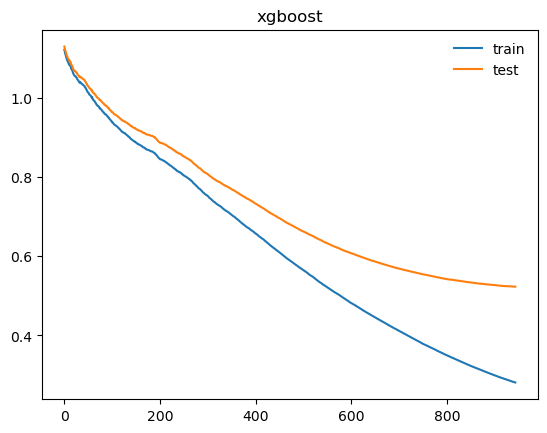

In [81]:
import matplotlib.pyplot as plt

plt.plot(cv_results['train-logloss-mean'],label='train')
plt.plot(cv_results['test-logloss-mean'],label='test')
plt.legend(frameon=False)
plt.title('xgboost')

In [82]:
num_boost_rounds = cv_results['test-logloss-mean'].idxmin()
xgb_model = xgb.train(params, dtrain, num_boost_round=num_boost_rounds)
print(num_boost_rounds)

943


In [83]:
# light gbm model
lgb_matrix = lgb.Dataset(X_train.drop(columns=['isic_id','target'],axis=1), label=Y_train, 
                         weight=train_weights)

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'eta': 0.01,
    'num_iterations':10000,
    'num_leaves':63,
    'random_state': 42,
    'verbose':-1
}

lgb_model = lgb.train(lgb_params, lgb_matrix, num_boost_round=1000)

In [84]:
# CatBoost model
cb_model = cb.CatBoostClassifier(iterations=10000, depth=6, learning_rate=0.01, 
                                 loss_function='Logloss', random_seed=42)

cb_model.fit(X_train.drop(columns=['isic_id','target'],axis=1), 
             Y_train, 
             sample_weight=train_weights, verbose=0)


### ROC analysis on these

In [61]:
len(X_test['isic_id'])

100265

In [129]:
# Y_val_pred = np.array([])
# Y_val_pred_proba = np.array([])
# for j in tqdm(range(0,len(X_val),1000)):
    
#     if len(X_val)-j>1000:
#         Y_val_pred = np.append(Y_val_pred,stacking_model.predict(X_val[j:j+1000]))
#         Y_val_pred_proba = np.append(Y_val_pred_proba,stacking_model.predict_proba(X_val[j:j+1000])[:,1])
#     else:
#         Y_val_pred = np.append(Y_val_pred,stacking_model.predict(X_val[j:]))
#         Y_val_pred_proba = np.append(Y_val_pred_proba,stacking_model.predict_proba(X_val[j:])[:,1])

dtest = xgb.DMatrix(X_test.drop(columns=['isic_id'],axis=1))

xgb_pred_proba = xgb_model.predict(dtest)
xgb_pred = np.array(xgb_pred_proba>0.5).astype(int)
print('finished xgb prediction')

finished xgb prediction


In [127]:
lgb_pred_proba = lgb_model.predict(X_test.drop(columns=['isic_id']))
lgb_pred = np.array(lgb_pred_proba>0.5).astype(int)
#lgb_pred_proba = lgb_model.predict_proba(X_test.drop(columns=['isic_id']))
print('finished lbg prediction')


finished lbg prediction


In [88]:

cb_pred = cb_model.predict(X_test.drop(columns=['isic_id']))
cb_pred_proba = cb_model.predict_proba(X_test.drop(columns=['isic_id']))
print('finished cb prediction')

finished cb prediction


In [130]:
accuracy_xgb = np.sum((xgb_pred==Y_test).astype(int)) / len(Y_test)
fp_xgb = np.sum(((xgb_pred==1)&(Y_test==0)).astype(int)) / len(Y_test)
fn_xgb = np.sum(((xgb_pred==0)&(Y_test==1)).astype(int)) / len(Y_test)

accuracy_xgb,fp_xgb,fn_xgb

(0.8387872138832095, 0.16114297112651474, 6.981499027576922e-05)

In [131]:
accuracy_lgb = np.sum((lgb_pred==Y_test).astype(int)) / len(Y_test)
fp_lgb = np.sum(((lgb_pred==1)&(Y_test==0)).astype(int)) / len(Y_test)
fn_lgb = np.sum(((lgb_pred==0)&(Y_test==1)).astype(int)) / len(Y_test)

accuracy_lgb,fp_lgb,fn_lgb

(0.9990624844162969, 6.981499027576922e-05, 0.0008677005934274173)

In [98]:
accuracy_cb = np.sum((cb_pred==Y_test).astype(int)) / len(Y_test)
fp_cb = np.sum(((cb_pred==1)&(Y_test==0)).astype(int)) / len(Y_test)
fn_cb = np.sum(((cb_pred==0)&(Y_test==1)).astype(int)) / len(Y_test)

accuracy_cb,fp_cb,fn_cb

(0.9984740437839724, 0.0007380441829152745, 0.0007879120331122525)

In [151]:
composite_proba = np.mean(np.array([xgb_pred_proba,
                                    lgb_pred_proba,
                                    cb_pred_proba[:,1]]),axis=0)
composite_pred = np.array(composite_proba>0.5).astype(int)

accuracy_comp = np.sum((composite_pred==Y_test).astype(int)) / len(Y_test)
fp_comp = np.sum(((composite_pred==1)&(Y_test==0)).astype(int)) / len(Y_test)
fn_comp = np.sum(((composite_pred==0)&(Y_test==1)).astype(int)) / len(Y_test)

accuracy_comp,fp_comp,fn_comp

(0.9984142023637361, 0.0008278063132698349, 0.0007579913229940657)

0.16322646479771508
0.1398998419432659
0.11844949116823332
0.1635553337215428


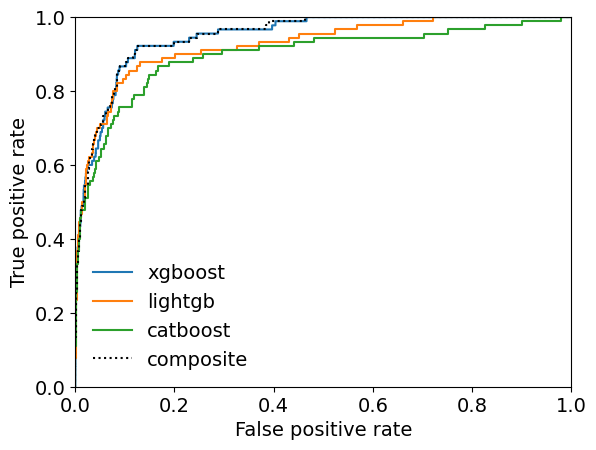

In [152]:
from sklearn.metrics import roc_curve, auc
from scipy.integrate import trapezoid
from matplotlib import rcParams

rcParams['font.size']=14

fpr_xgb, tpr_xgb, thresholds = roc_curve(Y_test,xgb_pred_proba)
score_xgb = trapezoid(tpr_xgb[tpr_xgb>0.8]-0.8,fpr_xgb[tpr_xgb>0.8])
print(score_xgb)

plt.plot(fpr_xgb,tpr_xgb,label='xgboost')
###

fpr_lgb, tpr_lgb, thresholds = roc_curve(Y_test,lgb_pred_proba)
score_lgb = trapezoid(tpr_lgb[tpr_lgb>0.8]-0.8,fpr_lgb[tpr_lgb>0.8])
print(score_lgb)

plt.plot(fpr_lgb,tpr_lgb,label='lightgb')
###

fpr_cb, tpr_cb, thresholds = roc_curve(Y_test,cb_pred_proba[:,1])
score_cb = trapezoid(tpr_cb[tpr_cb>0.8]-0.8,fpr_cb[tpr_cb>0.8])
print(score_cb)

plt.plot(fpr_cb,tpr_cb,label='catboost')
####
fpr_comp, tpr_comp, thresholds = roc_curve(Y_test,composite_proba)
score_comp = trapezoid(tpr_comp[tpr_comp>0.8]-0.8,fpr_comp[tpr_comp>0.8])
print(score_comp)

plt.plot(fpr_comp,tpr_comp,label='composite',color='k',ls=':')

####
plt.legend(frameon=False)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')

plt.xlim(0,1)
plt.ylim(0,1)

plt.savefig('metadata_only_GBDT_results.png',dpi=300,bbox_inches='tight')